# 배터리 건강 EDA — 통합 분석 노트북

**Severson et al., Nature Energy 2019** 데이터셋 기반

| 질문 | 주제 |
|------|------|
| Q1 | Cycle Life 분포 |
| Q2 | 열화 곡선 (QD vs Cycle) |
| Q3 | ΔQ(V) 곡선 분석 |
| Q4 | 충전 조건(C-rate)과 수명 관계 |
| Q5 | 피처 상관관계 & 다중공선성(VIF) |

## 0. 환경 설정 및 공통 유틸리티

In [1]:
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from __future__ import annotations
import gc, os, re, warnings
from pathlib import Path

import mat73
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.ndimage import gaussian_filter1d
from scipy import stats as scipy_stats
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

# ── 경로 설정 ──────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
REPO_ROOT    = NOTEBOOK_DIR.parent
DATA_DIR     = REPO_ROOT / 'data'
FIG_DIR      = REPO_ROOT / 'figures' / 'eda_day1'
FIG_DIR.mkdir(parents=True, exist_ok=True)

BATCH_FILES = [
    ('Batch1', '2017-05-12_batchdata_updated_struct_errorcorrect.mat'),
    ('Batch2', '2018-02-20_batchdata_updated_struct_errorcorrect.mat'),
    ('Batch3', '2018-04-12_batchdata_updated_struct_errorcorrect.mat'),
]

# ── 공통 로더 ──────────────────────────────────────────
def load_mat(path):
    return mat73.loadmat(str(path))

def batch_to_cells(batch):
    if isinstance(batch, dict):
        keys = list(batch.keys())
        n = len(batch[keys[0]])
        return [{k: batch[k][i] for k in keys} for i in range(n)]
    return batch

def cycles_to_list(cycles_raw):
    if isinstance(cycles_raw, dict):
        keys = list(cycles_raw.keys())
        n = len(cycles_raw[keys[0]])
        return [{k: cycles_raw[k][i] for k in keys} for i in range(n)]
    return cycles_raw

def safe_qdlin(cycle_dict):
    q = cycle_dict.get('Qdlin')
    if q is None:
        return None
    a = np.asarray(q, dtype=float).ravel()
    if a.size == 0 or not np.any(np.isfinite(a)):
        return None
    return a

def extract_summary(batch):
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        qd  = np.asarray(summary['QDischarge'], dtype=float).ravel()
        qc  = np.asarray(summary['QCharge'],    dtype=float).ravel()
        ir  = np.asarray(summary['IR'],          dtype=float).ravel()
        tmax = np.asarray(summary['Tmax'],       dtype=float).ravel()
        tavg = np.asarray(summary['Tavg'],       dtype=float).ravel()
        tmin = np.asarray(summary['Tmin'],       dtype=float).ravel()
        ct   = np.asarray(summary['chargetime'], dtype=float).ravel()
        cl_raw = np.asarray(cell['cycle_life']).ravel()
        if cl_raw.size == 0 or not np.isfinite(float(cl_raw[0])):
            continue
        cycle_life = int(cl_raw[0])
        policy = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        for c in range(len(qd)):
            records.append({
                'cell_id': i, 'cycle': c+1, 'cycle_life': cycle_life,
                'charging_policy': policy,
                'QD': qd[c], 'QC': qc[c], 'IR': ir[c],
                'Tmax': tmax[c], 'Tavg': tavg[c], 'Tmin': tmin[c],
                'chargetime': ct[c]
            })
    return pd.DataFrame(records)

def parse_primary_crate(policy):
    m = re.search(r'([\d.]+)\s*C', policy, re.I)
    return float(m.group(1)) if m else None

def parse_second_crate(policy):
    for part in reversed(policy.split('-')):
        m = re.search(r'^([\d.]+)\s*C', part.strip(), re.I)
        if m:
            return float(m.group(1))
    return None

def parse_switch_pct(policy):
    m = re.search(r'\(([\d.]+)%\)', policy)
    return float(m.group(1)) if m else None

def knee_cycle_from_qd(qd, cyc):
    mask = (cyc >= 5) & np.isfinite(qd) & (qd > 0.1)
    if mask.sum() < 30:
        return None
    y = qd[mask].astype(float)
    x = cyc[mask].astype(float)
    order = np.argsort(x)
    y, x = y[order], x[order]
    y_s = gaussian_filter1d(y, sigma=2)
    d2 = np.diff(y_s, n=2)
    if len(d2) < 5:
        return None
    k = int(np.argmin(d2)) + 1
    return int(x[k])

def delta_q_features(cell):
    cycles = cycles_to_list(cell['cycles'])
    if len(cycles) < 100:
        return None
    q10  = safe_qdlin(cycles[9])
    q100 = safe_qdlin(cycles[99])
    if q10 is None or q100 is None or q10.shape != q100.shape:
        return None
    dq = q100 - q10
    finite = np.isfinite(dq)
    if not np.any(finite):
        return None
    dq = dq[finite]
    return {
        'dq_mean': float(np.mean(dq)),
        'dq_std':  float(np.std(dq)),
        'dq_min':  float(np.min(dq)),
        'dq_max':  float(np.max(dq)),
        'dq_l2':   float(np.sqrt(np.sum(dq**2))),
        'dq_abs_mean': float(np.mean(np.abs(dq))),
    }

def compute_vif(df):
    X = df.to_numpy(dtype=float)
    values = []
    for i, col in enumerate(df.columns):
        y = X[:, i]
        others = np.column_stack([np.ones(len(X)), np.delete(X, i, axis=1)])
        beta, *_ = np.linalg.lstsq(others, y, rcond=None)
        pred = others @ beta
        ss_res = np.sum((y - pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - ss_res / ss_tot if ss_tot else 1.0
        vif = np.inf if r2 >= 1 else 1 / (1 - r2)
        values.append({'feature': col, 'r2': round(r2, 4), 'VIF': round(vif, 2)})
    return pd.DataFrame(values).sort_values('VIF', ascending=False)

print('✅ 환경 설정 완료')
print(f'DATA_DIR: {DATA_DIR}')
print(f'FIG_DIR : {FIG_DIR}')

✅ 환경 설정 완료
DATA_DIR: /Users/toucan/Documents/workspace/ESS/data
FIG_DIR : /Users/toucan/Documents/workspace/ESS/figures/eda_day1


## 폰트 설정

In [3]:
import platform

# OS에 따른 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin': # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux (Colab 등)
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

## 데이터 로딩 (전체 배치)

In [4]:
all_meta = {}   # batch_name -> meta DataFrame
all_df   = {}   # batch_name -> full summary DataFrame
all_batch_cells = {}  # batch_name -> raw cell list

for batch_name, mat_file in BATCH_FILES:
    path = DATA_DIR / mat_file
    if not path.is_file():
        print(f'[SKIP] 파일 없음: {path}')
        continue
    print(f'로딩 중: {batch_name} ...')
    mat = load_mat(path)
    batch = batch_to_cells(mat['batch'])
    del mat; gc.collect()

    df = extract_summary(batch)
    meta = df.drop_duplicates('cell_id')[['cell_id','cycle_life','charging_policy']].copy()
    meta['batch'] = batch_name
    meta['c1']  = meta['charging_policy'].map(parse_primary_crate)
    meta['c2']  = meta['charging_policy'].map(parse_second_crate)
    meta['switch_pct'] = meta['charging_policy'].map(parse_switch_pct)

    all_df[batch_name]   = df
    all_meta[batch_name] = meta
    all_batch_cells[batch_name] = batch
    print(f'  -> {len(meta)} cells, {len(df)} rows')

LOADED_BATCHES = list(all_meta.keys())
print(f'\n총 로딩된 배치: {LOADED_BATCHES}')

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중: Batch1 ...


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

  -> 46 cells, 38811 rows
로딩 중: Batch2 ...


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

  -> 39 cells, 23034 rows
로딩 중: Batch3 ...
  -> 44 cells, 46581 rows

총 로딩된 배치: ['Batch1', 'Batch2', 'Batch3']


---
## Q1. Cycle Life 분포는 어떻게 생겼는가?

- 150 ~ 2,300 사이클 Histogram
- 장수명 (>1,000) / 단수명 (<500) 비율 확인
- 이상치 셀 식별

In [5]:
print('='*60)
print('Q1. Cycle Life 분포 통계')
print('='*60)

for bname in LOADED_BATCHES:
    cl = all_meta[bname]['cycle_life'].values
    long_pct  = 100.0 * np.mean(cl > 1000)
    short_pct = 100.0 * np.mean(cl < 500)
    in_range  = 100.0 * np.mean((cl >= 150) & (cl <= 2300))
    print(f'\n[{bname}] n={len(cl)}')
    print(f'  min={cl.min()}, max={cl.max()}, mean={cl.mean():.1f}, median={np.median(cl):.1f}, std={cl.std():.1f}')
    print(f'  [150~2300] 범위 내 셀: {in_range:.1f}%')
    print(f'  장수명(>1000): {long_pct:.1f}% | 단수명(<500): {short_pct:.1f}%')
    skew = float(scipy_stats.skew(cl, bias=False))
    print(f'  Skewness: {skew:.3f}')

    thr = np.percentile(cl, 10)
    outliers = all_meta[bname][all_meta[bname]['cycle_life'] <= max(300, thr)]
    print(f'  이상치 셀 (≤max(300, 10th percentile={thr:.0f})):  {len(outliers)}개')
    if len(outliers) > 0:
        display(outliers[['cell_id','cycle_life','charging_policy']].sort_values('cycle_life').head(10))

Q1. Cycle Life 분포 통계

[Batch1] n=46
  min=534, max=1227, mean=844.7, median=858.5, std=182.6
  [150~2300] 범위 내 셀: 100.0%
  장수명(>1000): 21.7% | 단수명(<500): 0.0%
  Skewness: 0.453
  이상치 셀 (≤max(300, 10th percentile=621)):  5개


,cell_id,cycle_life,charging_policy
18782,20,534,5.4C(80%)-5.4C
19315,21,559,5.4C(80%)-5.4C
38213,45,599,8C(35%)-3.6C
37598,44,616,8C(35%)-3.6C
32992,38,617,7C(40%)-3.6C



[Batch2] n=39
  min=392, max=1186, mean=565.7, median=472.0, std=219.3
  [150~2300] 범위 내 셀: 100.0%
  장수명(>1000): 7.7% | 단수명(<500): 71.8%
  Skewness: 1.637
  이상치 셀 (≤max(300, 10th percentile=411)):  4개


,cell_id,cycle_life,charging_policy
10153,19,392,6C(60%)-3C
2874,6,393,3.6C(9%)-5C
8279,15,396,3.6C(9%)-5C
11070,21,408,6C(60%)-3C



[Batch3] n=44
  min=541, max=1935, mean=1059.7, median=1005.5, std=310.3
  [150~2300] 범위 내 셀: 100.0%
  장수명(>1000): 52.3% | 단수명(<500): 0.0%
  Skewness: 1.255
  이상치 셀 (≤max(300, 10th percentile=789)):  5개


,cell_id,cycle_life,charging_policy
27583,28,541,3.7C(31%)-5.9C-newstructure
6324,6,667,3.7C(31%)-5.9C-newstructure
29914,31,731,5.9C(60%)-3.1C-newstructure
22123,21,772,3.7C(31%)-5.9C-newstructure
40371,41,786,5.6C(36%)-4.3C-newstructure


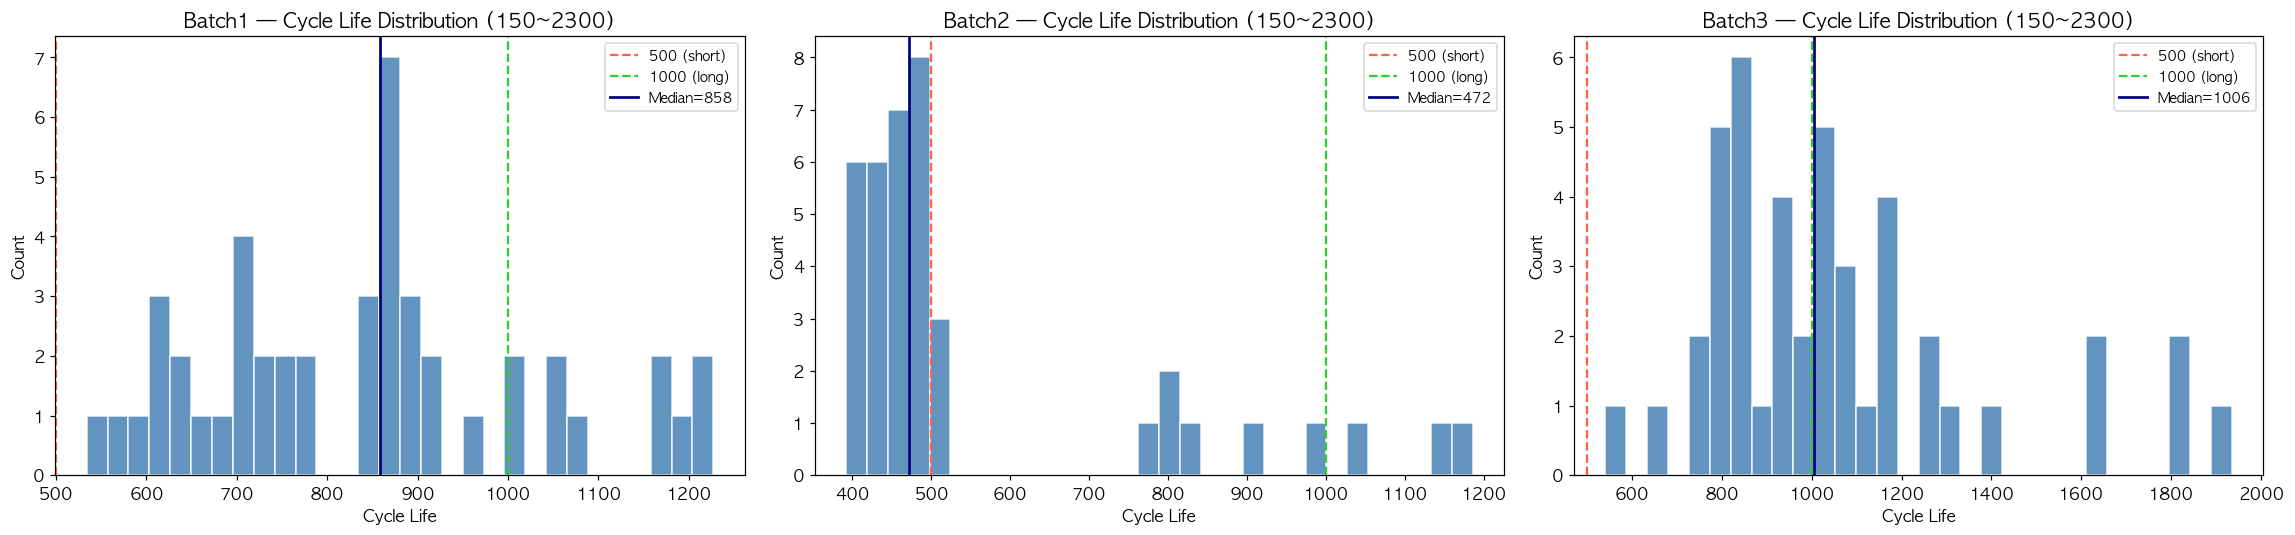

저장: /Users/toucan/Documents/workspace/ESS/figures/eda_day1/q1_cycle_life_hist.png


In [6]:
n_batches = len(LOADED_BATCHES)
fig, axes = plt.subplots(1, n_batches, figsize=(7*n_batches, 5), sharey=False)
if n_batches == 1:
    axes = [axes]

for ax, bname in zip(axes, LOADED_BATCHES):
    cl = all_meta[bname]['cycle_life'].values
    cl_range = cl[(cl >= 150) & (cl <= 2300)]
    ax.hist(cl_range, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(500,  color='tomato',    linestyle='--', linewidth=1.5, label='500 (short)')
    ax.axvline(1000, color='limegreen', linestyle='--', linewidth=1.5, label='1000 (long)')
    ax.axvline(float(np.median(cl_range)), color='navy', linestyle='-', linewidth=1.8,
               label=f'Median={np.median(cl_range):.0f}')
    ax.set_xlabel('Cycle Life')
    ax.set_ylabel('Count')
    ax.set_title(f'{bname} — Cycle Life Distribution (150~2300)', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / 'q1_cycle_life_hist.png', dpi=130)
plt.show()
print('저장:', FIG_DIR / 'q1_cycle_life_hist.png')

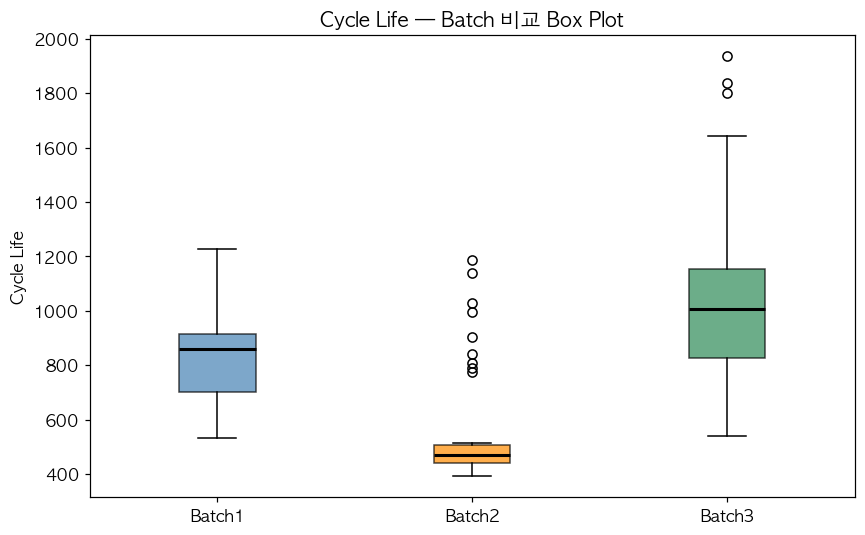

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [all_meta[b]['cycle_life'].values for b in LOADED_BATCHES]
bp = ax.boxplot(data_to_plot, labels=LOADED_BATCHES, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
colors = ['steelblue', 'darkorange', 'seagreen']
for patch, color in zip(bp['boxes'], colors[:len(LOADED_BATCHES)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Cycle Life')
ax.set_title('Cycle Life — Batch 비교 Box Plot', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'q1_cycle_life_boxplot.png', dpi=130)
plt.show()

---
## Q2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?

- 사이클별 QD 추이 시각화
- 열화 속도 패턴 분석 (일정 vs 가속)
- Knee point 탐색

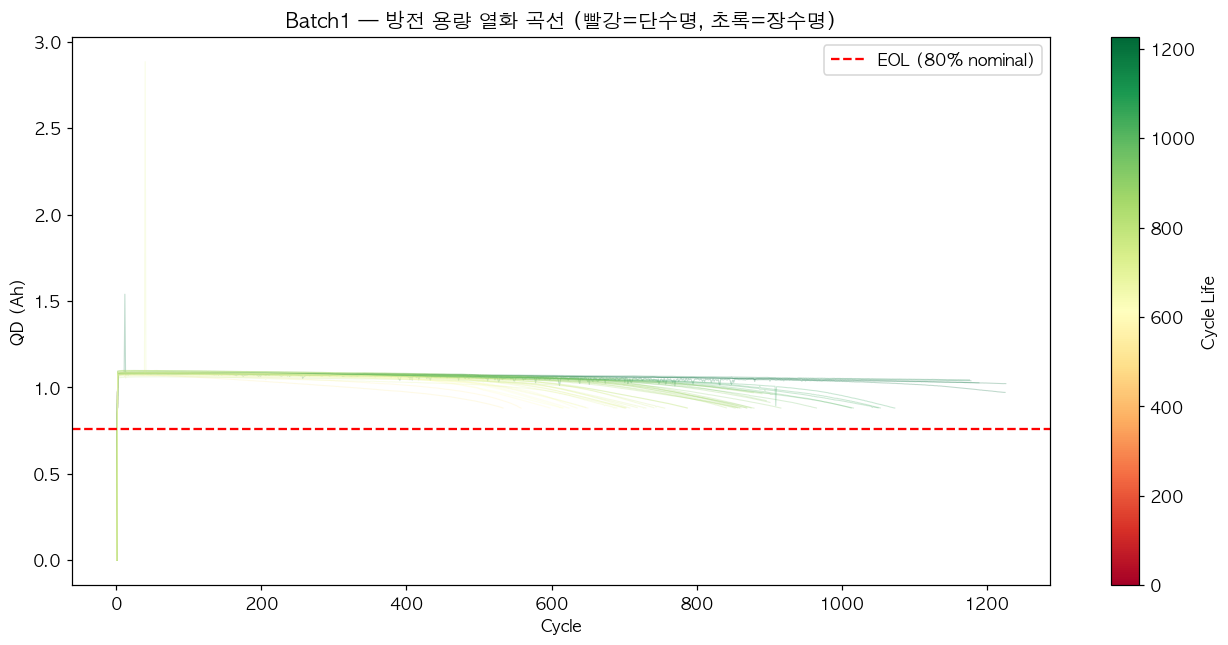

[Batch1] nominal QD = 0.8636 Ah, EOL threshold = 0.7600 Ah


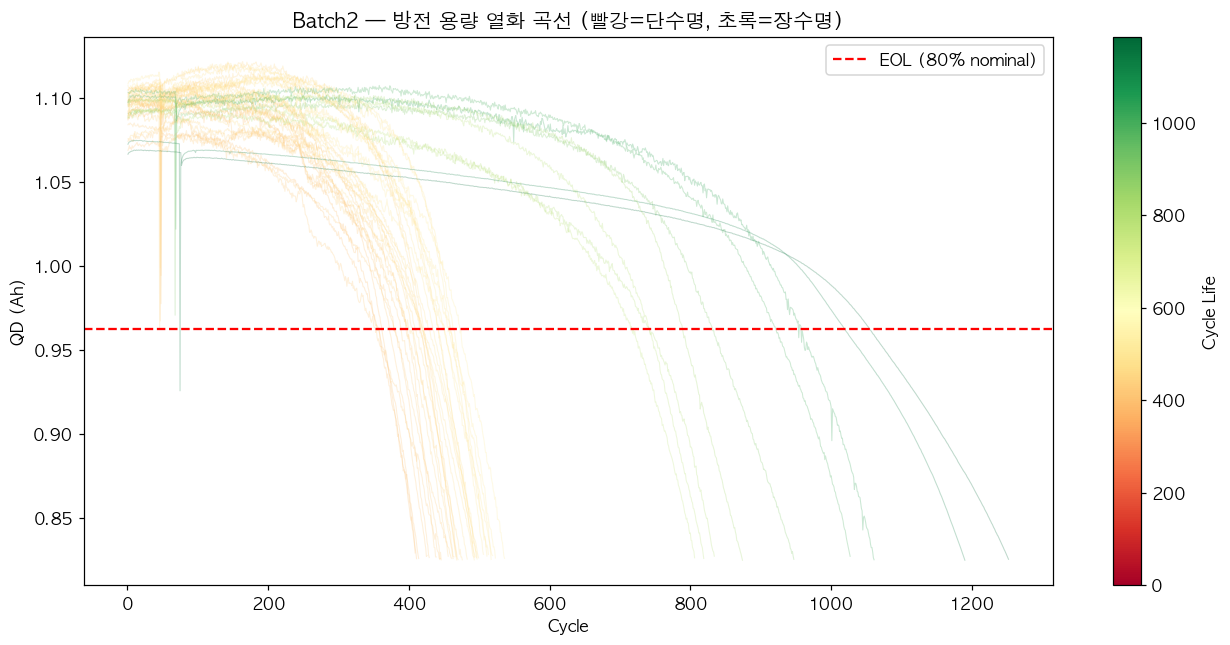

[Batch2] nominal QD = 1.0939 Ah, EOL threshold = 0.9627 Ah


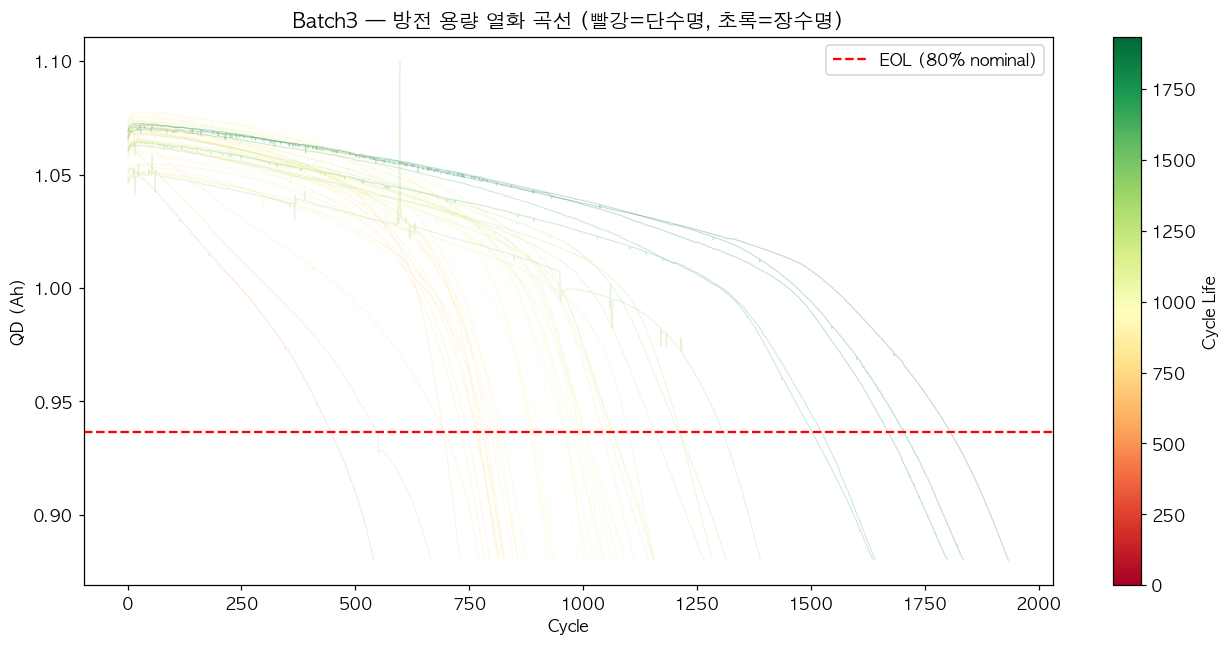

[Batch3] nominal QD = 1.0642 Ah, EOL threshold = 0.9365 Ah


In [8]:
for bname in LOADED_BATCHES:
    df   = all_df[bname]
    meta = all_meta[bname]

    # outlier 필터 (QD 이상치 제거)
    nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
    valid_ids = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean()
    valid_ids = valid_ids[valid_ids > 0.7 * nominal].index
    df_clean = df[df['cell_id'].isin(valid_ids)].copy()

    life_map = meta.set_index('cell_id')['cycle_life']
    max_life = meta['cycle_life'].max()

    fig, ax = plt.subplots(figsize=(12, 6))
    for cell_id, grp in df_clean.groupby('cell_id'):
        cl = life_map.get(cell_id, 500)
        color = cm.RdYlGn(cl / max_life)
        ax.plot(grp['cycle'], grp['QD'], alpha=0.25, linewidth=0.7, color=color)

    ax.axhline(y=0.88 * nominal, color='red', linestyle='--', linewidth=1.5, label='EOL (80% nominal)')
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=0, vmax=max_life))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Cycle Life')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('QD (Ah)')
    ax.set_title(f'{bname} — 방전 용량 열화 곡선 (빨강=단수명, 초록=장수명)', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'q2_{bname}_degradation_curve.png', dpi=130)
    plt.show()
    print(f'[{bname}] nominal QD = {nominal:.4f} Ah, EOL threshold = {0.88*nominal:.4f} Ah')

Q2. Knee Point 분석

[Batch1] Knee 감지된 셀: 46/46
  Knee 위치 (사이클 기준) — mean: 437.2, std: 299.8
  Knee 위치 (수명 대비 %) — mean: 51.9%, std: 33.2%


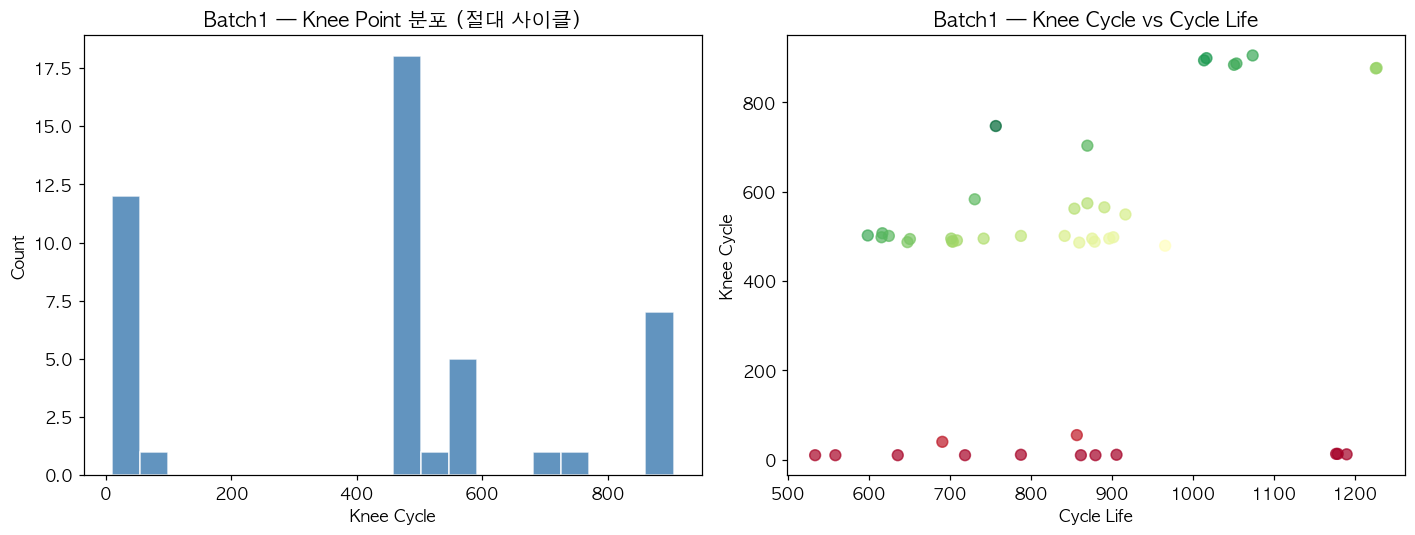


[Batch2] Knee 감지된 셀: 39/39
  Knee 위치 (사이클 기준) — mean: 150.8, std: 177.9
  Knee 위치 (수명 대비 %) — mean: 29.1%, std: 33.0%


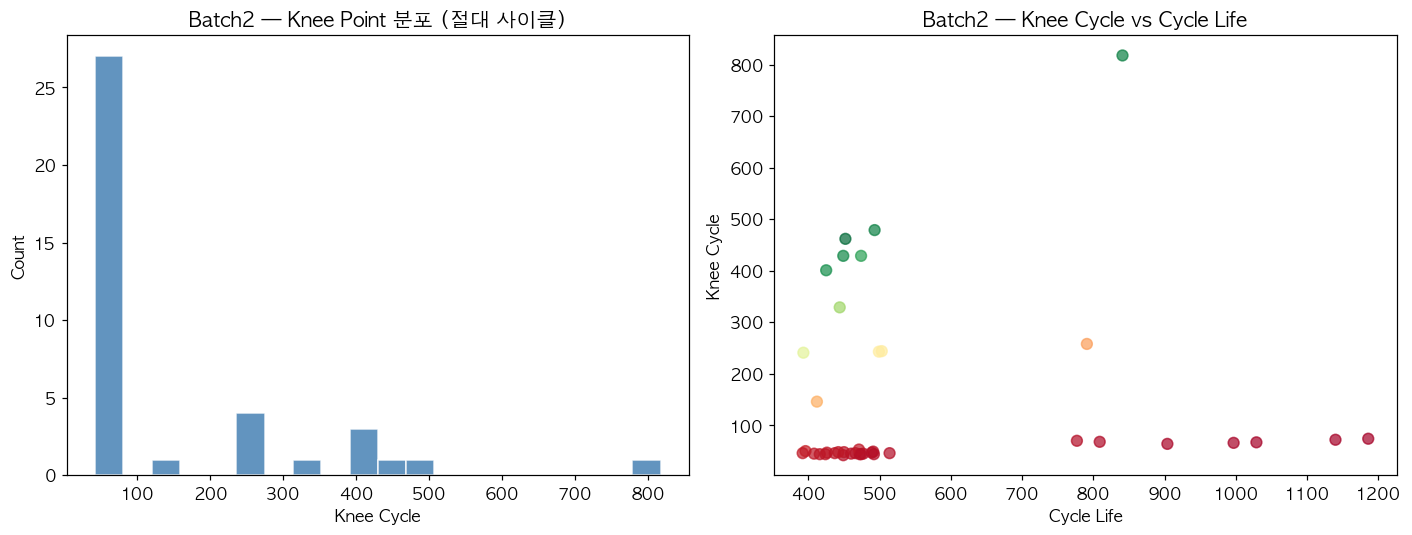


[Batch3] Knee 감지된 셀: 44/44
  Knee 위치 (사이클 기준) — mean: 348.7, std: 414.6
  Knee 위치 (수명 대비 %) — mean: 33.3%, std: 36.4%


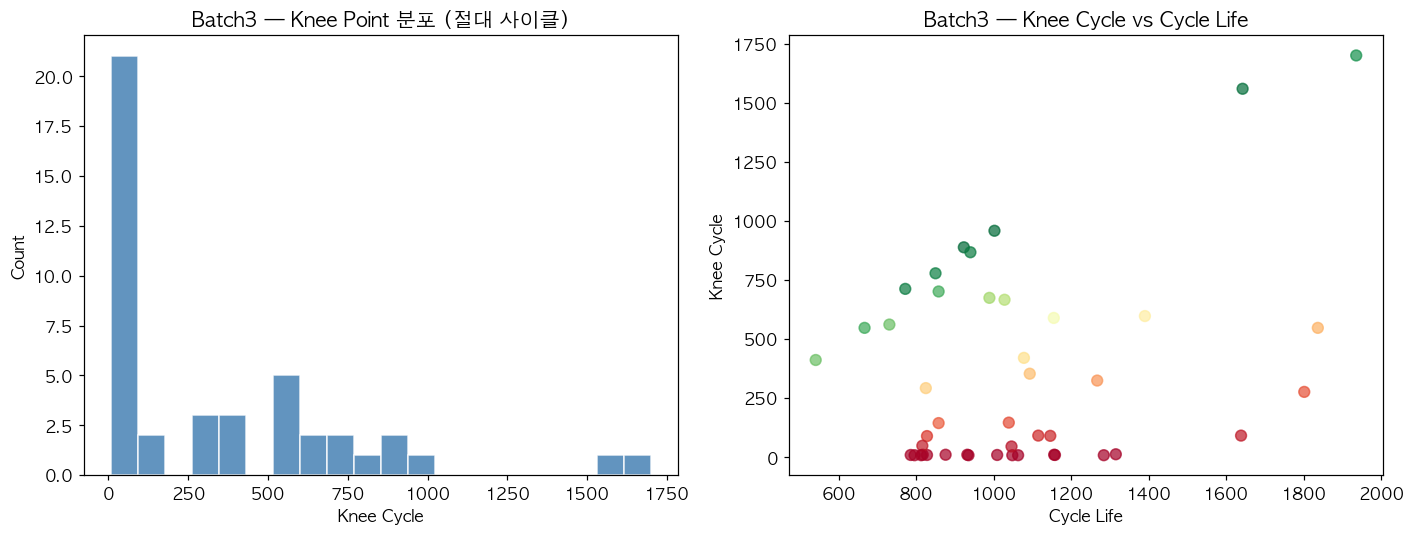

In [9]:
print('='*60)
print('Q2. Knee Point 분석')
print('='*60)

for bname in LOADED_BATCHES:
    df   = all_df[bname]
    meta = all_meta[bname]
    knee_list = []

    for cell_id, grp in df.groupby('cell_id'):
        qd  = grp['QD'].values
        cyc = grp['cycle'].values
        cl  = meta.loc[meta['cell_id'] == cell_id, 'cycle_life'].values
        if len(cl) == 0:
            continue
        life = int(cl[0])
        kc = knee_cycle_from_qd(qd, cyc)
        if kc is not None:
            knee_list.append({'cell_id': cell_id, 'knee_cycle': kc,
                              'cycle_life': life, 'knee_frac': kc / max(life, 1)})

    knee_df = pd.DataFrame(knee_list)
    print(f'\n[{bname}] Knee 감지된 셀: {len(knee_df)}/{len(meta)}')
    if len(knee_df) > 0:
        print(f'  Knee 위치 (사이클 기준) — mean: {knee_df["knee_cycle"].mean():.1f}, '
              f'std: {knee_df["knee_cycle"].std():.1f}')
        print(f'  Knee 위치 (수명 대비 %) — mean: {knee_df["knee_frac"].mean()*100:.1f}%, '
              f'std: {knee_df["knee_frac"].std()*100:.1f}%')

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].hist(knee_df['knee_cycle'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
        axes[0].set_xlabel('Knee Cycle')
        axes[0].set_ylabel('Count')
        axes[0].set_title(f'{bname} — Knee Point 분포 (절대 사이클)')

        axes[1].scatter(knee_df['cycle_life'], knee_df['knee_cycle'],
                        c=knee_df['knee_frac'], cmap='RdYlGn', alpha=0.7, s=50)
        axes[1].set_xlabel('Cycle Life')
        axes[1].set_ylabel('Knee Cycle')
        axes[1].set_title(f'{bname} — Knee Cycle vs Cycle Life')
        plt.tight_layout()
        fig.savefig(FIG_DIR / f'q2_{bname}_knee_point.png', dpi=130)
        plt.show()

---
## Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?

- Q(V) 차이: 사이클 100 − 사이클 10
- 장수명 vs 단수명 셀 ΔQ 형태 비교
- 피처 추출 (dq_mean, dq_std, dq_min, dq_max, dq_abs_mean)

In [ ]:
all_dq = {}  # batch_name -> dq_df

for bname in LOADED_BATCHES:
    cells = all_batch_cells[bname]
    meta  = all_meta[bname]
    dq_rows = []
    for i, cell in enumerate(cells):
        cl_raw = np.asarray(cell['cycle_life']).ravel()
        if cl_raw.size == 0 or not np.isfinite(float(cl_raw[0])):
            continue
        life = int(cl_raw[0])
        dq = delta_q_features(cell)
        if dq is not None:
            dq['cell_id'] = i
            dq['cycle_life'] = life
            dq['batch'] = bname
            dq_rows.append(dq)
    dq_df = pd.DataFrame(dq_rows)
    all_dq[bname] = dq_df
    print(f'[{bname}] ΔQ 계산 셀: {len(dq_df)}/{len(meta)}')

# 통합 dq DataFrame
dq_all = pd.concat(all_dq.values(), ignore_index=True)
print(f'\n전체 ΔQ 데이터: {len(dq_all)} 셀')

NameError: name 'batch1' is not defined

In [11]:
print('='*60)
print('Q3. ΔQ(V) 통계 — 장수명 vs 단수명')
print('='*60)

for bname in LOADED_BATCHES:
    dq_df = all_dq[bname]
    if dq_df.empty:
        continue
    long_  = dq_df[dq_df['cycle_life'] > 1000]
    short_ = dq_df[dq_df['cycle_life'] < 500]
    print(f'\n[{bname}]')
    print(f'  전체 dq_abs_mean: {dq_df["dq_abs_mean"].mean():.6f}')
    if len(long_) > 0:
        print(f'  장수명(>1000) dq_abs_mean: {long_["dq_abs_mean"].mean():.6f} (n={len(long_)})')
    if len(short_) > 0:
        print(f'  단수명(<500)  dq_abs_mean: {short_["dq_abs_mean"].mean():.6f} (n={len(short_)})')

    # dq pearson corr with cycle_life
    for feat in ['dq_mean', 'dq_std', 'dq_min', 'dq_max', 'dq_abs_mean']:
        r = np.corrcoef(dq_df['cycle_life'], dq_df[feat])[0, 1]
        print(f'  Pearson r({feat}, cycle_life): {r:+.4f}')

Q3. ΔQ(V) 통계 — 장수명 vs 단수명

[Batch1]
  전체 dq_abs_mean: 0.016029
  장수명(>1000) dq_abs_mean: 0.008694 (n=10)
  Pearson r(dq_mean, cycle_life): +0.8538
  Pearson r(dq_std, cycle_life): -0.8937
  Pearson r(dq_min, cycle_life): +0.8816
  Pearson r(dq_max, cycle_life): +0.2639
  Pearson r(dq_abs_mean, cycle_life): -0.8538

[Batch2]
  전체 dq_abs_mean: 0.025043
  장수명(>1000) dq_abs_mean: 0.009546 (n=3)
  단수명(<500)  dq_abs_mean: 0.030026 (n=28)
  Pearson r(dq_mean, cycle_life): +0.7671
  Pearson r(dq_std, cycle_life): -0.8345
  Pearson r(dq_min, cycle_life): +0.8185
  Pearson r(dq_max, cycle_life): +0.4981
  Pearson r(dq_abs_mean, cycle_life): -0.7649

[Batch3]
  전체 dq_abs_mean: 0.011221
  장수명(>1000) dq_abs_mean: 0.008515 (n=23)
  Pearson r(dq_mean, cycle_life): +0.6391
  Pearson r(dq_std, cycle_life): -0.6726
  Pearson r(dq_min, cycle_life): +0.6921
  Pearson r(dq_max, cycle_life): +0.4077
  Pearson r(dq_abs_mean, cycle_life): -0.6294


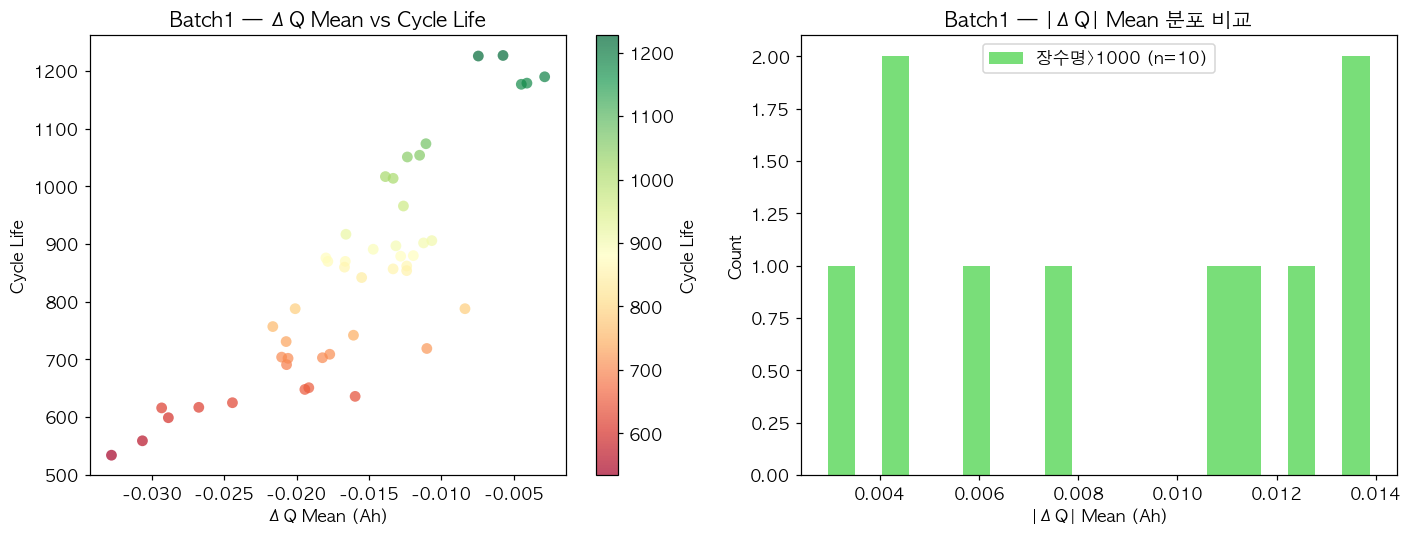

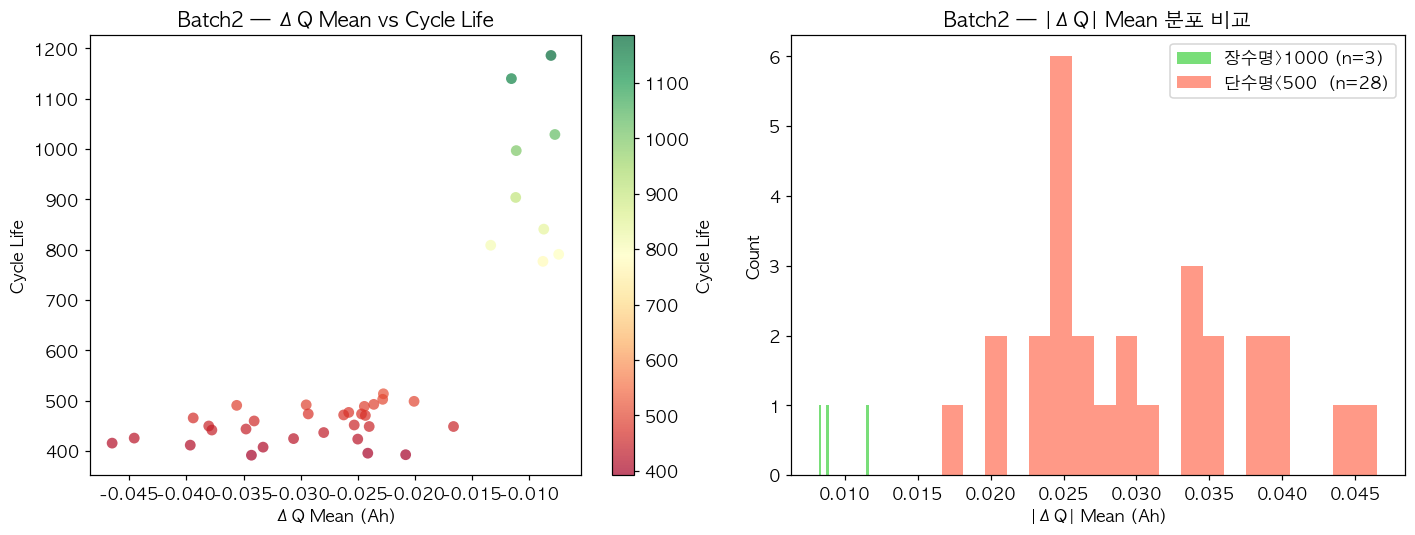

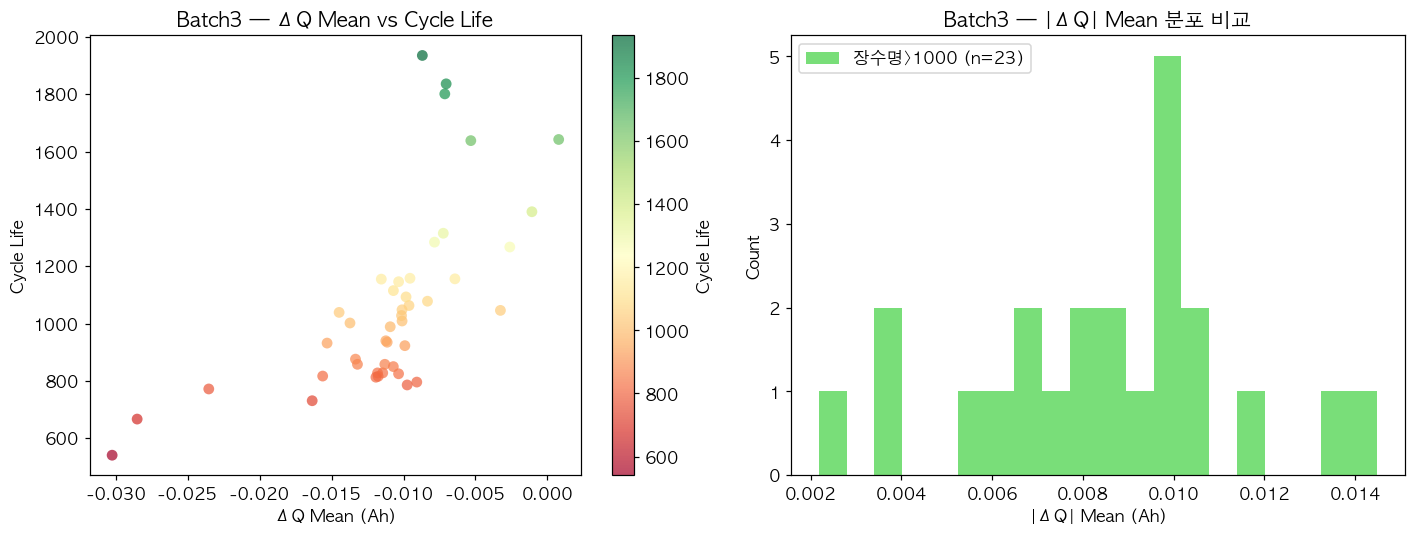

In [12]:
for bname in LOADED_BATCHES:
    dq_df = all_dq[bname]
    if dq_df.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # scatter: dq_mean vs cycle_life
    ax = axes[0]
    sc = ax.scatter(dq_df['dq_mean'], dq_df['cycle_life'],
                    c=dq_df['cycle_life'], cmap='RdYlGn', alpha=0.7, s=50, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Cycle Life')
    ax.set_xlabel('ΔQ Mean (Ah)')
    ax.set_ylabel('Cycle Life')
    ax.set_title(f'{bname} — ΔQ Mean vs Cycle Life', fontweight='bold')

    # histogram: 장수명 vs 단수명 dq_abs_mean
    ax = axes[1]
    long_  = dq_df[dq_df['cycle_life'] > 1000]['dq_abs_mean']
    short_ = dq_df[dq_df['cycle_life'] < 500]['dq_abs_mean']
    if len(long_) > 0:
        ax.hist(long_,  bins=20, alpha=0.65, color='limegreen', label=f'장수명>1000 (n={len(long_)})')
    if len(short_) > 0:
        ax.hist(short_, bins=20, alpha=0.65, color='tomato',    label=f'단수명<500  (n={len(short_)})')
    ax.set_xlabel('|ΔQ| Mean (Ah)')
    ax.set_ylabel('Count')
    ax.set_title(f'{bname} — |ΔQ| Mean 분포 비교', fontweight='bold')
    ax.legend()

    plt.tight_layout()
    fig.savefig(FIG_DIR / f'q3_{bname}_delta_q.png', dpi=130)
    plt.show()

### 사이클 100번 - 사이클 10번의 Q(V) 차이 계산

In [ ]:
# ── 1. 배치별 ΔQ(V) 곡선 전체 ──────────────────────────────────

def _parse_cycles(cell):
    """cell['cycles']를 list-of-dicts(np.array 값) 형태로 변환 — 30-ESSHealth-scratch-sumin.ipynb 참조"""
    raw = cell['cycles']
    if isinstance(raw, dict):
        keys = list(raw.keys())
        n = len(raw[keys[0]])
        return [{k: np.array(raw[k][i]) for k in keys} for i in range(n)]
    return [{k: np.array(v) for k, v in c.items()} for c in raw]

def get_dq_curves(cells, cycle_a=10, cycle_b=100):
    dq_list = []
    for i, cell in enumerate(cells):
        try:
            cl_val = cell.get('cycle_life')
            cl_scalar = float(np.array(cl_val).flat[0])
            if np.isnan(cl_scalar):
                continue
            cycle_life = int(cl_scalar)

            cycles = _parse_cycles(cell)
            if len(cycles) < cycle_b:
                continue

            cy_a = cycles[cycle_a - 1]
            cy_b = cycles[cycle_b - 1]

            if 'Qdlin' not in cy_a or 'Qdlin' not in cy_b:
                continue

            q_a = cy_a['Qdlin'].ravel()
            q_b = cy_b['Qdlin'].ravel()
            if q_a.shape != q_b.shape:
                continue

            v_arr = cy_b.get('Vdlin', cy_a.get('Vdlin', np.linspace(2.0, 3.5, len(q_b))))
            v = np.array(v_arr).ravel() if hasattr(v_arr, '__len__') else np.linspace(2.0, 3.5, len(q_b))

            policy = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
            dq_list.append({
                'cell_id'    : i,
                'cycle_life' : cycle_life,
                'policy'     : policy,
                'V'          : v.astype(float),
                'dQ'         : (q_b - q_a).astype(float),
            })
        except Exception:
            continue
    return dq_list

print("ΔQ(V) 커브 수집 중...")
dQ1 = get_dq_curves(all_batch_cells['Batch1'])
dQ2 = get_dq_curves(all_batch_cells['Batch2'])
dQ3 = get_dq_curves(all_batch_cells['Batch3'])
print(f"완료! Batch1: {len(dQ1)}개, Batch2: {len(dQ2)}개, Batch3: {len(dQ3)}개")



for bname, dq in [('Batch 1', dQ1), ('Batch 2', dQ2), ('Batch 3', dQ3)]:
    if not dq:
        print(f'{bname}: 유효한 ΔQ 커브 없음, 스킵')
        continue
    lives  = np.array([d['cycle_life'] for d in dq])
    colors = cm.coolwarm(np.linspace(0, 1, len(dq)))
    order  = np.argsort(lives)

    fig, ax = plt.subplots(figsize=(12, 5))

    for rank, idx in enumerate(order):
        ax.plot(dq[idx]['V'], dq[idx]['dQ'],
                color=colors[rank], linewidth=0.7, alpha=0.6)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('ΔQ = Q(100) − Q(10)  (Ah)')
    ax.set_title(f'{bname}  ΔQ(V)  (n={len(dq)})', fontsize=13, fontweight='bold')

    sm = cm.ScalarMappable(cmap='coolwarm',
         norm=plt.Normalize(vmin=lives.min(), vmax=lives.max()))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Cycle Life')

    plt.tight_layout()
    plt.show()


In [ ]:
# ── 2. 장수명(>1000) vs 단수명(<500) ΔQ 형태 비교 ──────────────
LONG_TH  = 1000
SHORT_TH = 500

for bname, dq in [('Batch 1', dQ1), ('Batch 2', dQ2), ('Batch 3', dQ3)]:
    long_cells  = [d for d in dq if d['cycle_life'] >  LONG_TH]
    short_cells = [d for d in dq if d['cycle_life'] < SHORT_TH]

    fig, ax = plt.subplots(figsize=(12, 5))

    def plot_group(cells, color, label):
        if not cells:
            return
        V   = cells[0]['V']
        mat = np.vstack([d['dQ'] for d in cells])
        mean = mat.mean(axis=0)
        std  = mat.std(axis=0)
        for row in mat:
            ax.plot(V, row, color=color, linewidth=0.5, alpha=0.25)
        ax.plot(V, mean, color=color, linewidth=2.0,
                label=f'{label}  (n={len(cells)})')
        ax.fill_between(V, mean - std, mean + std, color=color, alpha=0.15)

    plot_group(long_cells,  'tomato', f'>  {LONG_TH} (long)')
    plot_group(short_cells, 'steelblue',    f'< {SHORT_TH} (short)')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('ΔQ (Ah)')
    ax.set_title(f'{bname}  —  Long-life vs Short-life  ΔQ(V)  (mean ± 1σ)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


In [ ]:
# ── 3. ΔQ 통계 피처 추출 ─────────────────────────────────────
def dQ_features(dq_list, batch_name):
    rows = []
    for d in dq_list:
        x = d['dQ']
        rows.append({
            'batch'        : batch_name,
            'cell_id'      : d['cell_id'],
            'cycle_life'   : d['cycle_life'],
            'dQ_min'       : x.min(),
            'dQ_mean'      : x.mean(),
            'dQ_var'       : x.var(),
            'log_dQ_var'   : np.log(x.var() + 1e-10),
            'dQ_skew'      : scipy_stats.skew(x),
            'dQ_kurt'      : scipy_stats.kurtosis(x),
            'dQ_min_loc'   : d['V'][np.argmin(x)],   # 최솟값 위치 전압
        })
    return pd.DataFrame(rows)

feat1 = dQ_features(dQ1, 'Batch 1')
feat2 = dQ_features(dQ2, 'Batch 2')
feat3 = dQ_features(dQ3, 'Batch 3')
feat_all = pd.concat([feat1, feat2, feat3], ignore_index=True)

print(feat_all.groupby('batch').describe().round(3).T)

# ── 피처별 cycle_life 산점도 (3 / 2 배치) ────────────────────
feat_cols  = ['dQ_min', 'log_dQ_var', 'dQ_skew', 'dQ_kurt', 'dQ_min_loc']
colors_map = {'Batch 1': 'steelblue', 'Batch 2': 'tomato', 'Batch 3': 'seagreen'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# 마지막 칸(2행 3열) 비우기
axes[1, 2].set_visible(False)
ax_list = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, col in zip(ax_list, feat_cols):
    for bname, grp in feat_all.groupby('batch'):
        ax.scatter(grp[col], grp['cycle_life'],
                   label=bname, alpha=0.7, s=30,
                   color=colors_map[bname], edgecolors='white', linewidths=0.3)
    r = feat_all[col].corr(feat_all['cycle_life'])
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Cycle Life')
    ax.set_title(f'{col}  (r={r:+.3f})')

ax_list[0].legend(fontsize=8)

# Pearson r 출력
print("\n[피처 × cycle_life  Pearson r  (전체 배치 합산)]")
for col in feat_cols:
    r = feat_all[col].corr(feat_all['cycle_life'])
    print(f"  {col:20s} : {r:+.3f}")

plt.suptitle('ΔQ Features vs Cycle Life  (by Batch)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q4. 충전 조건 (C-rate)과 수명의 관계

- 충전 프로토콜별 평균 수명 비교
- 고속 충전 셀의 수명 분석
- 충전 전류 패턴 × 열화 속도 상관 분석

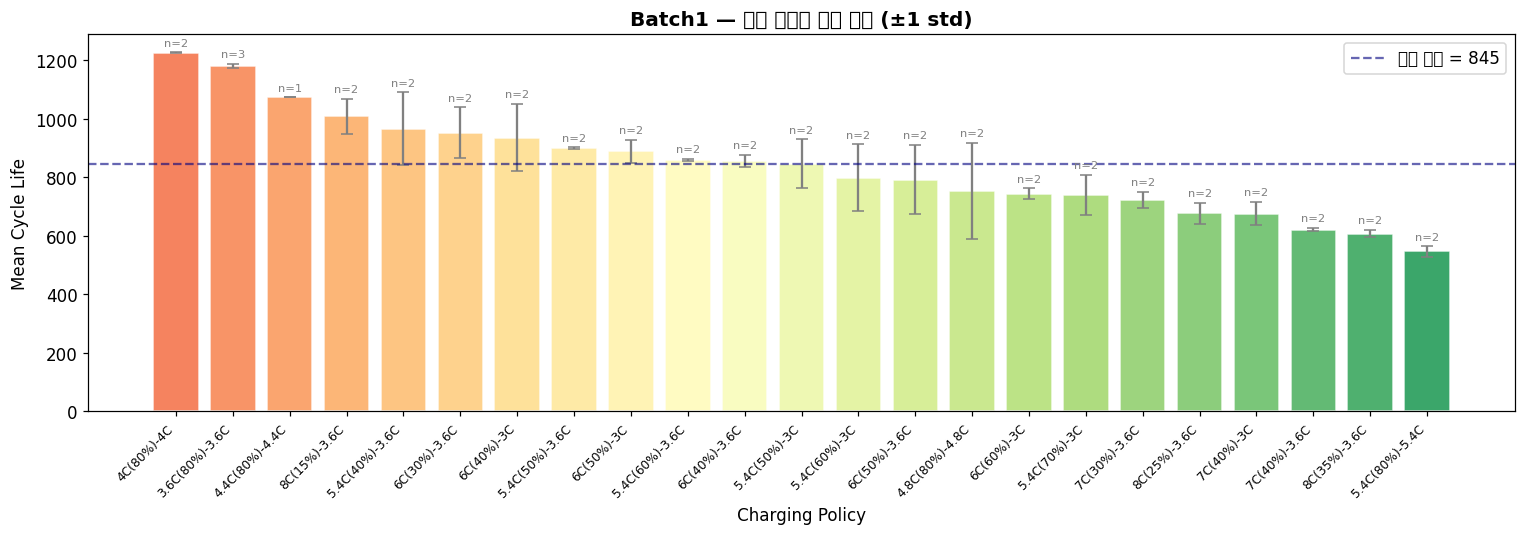

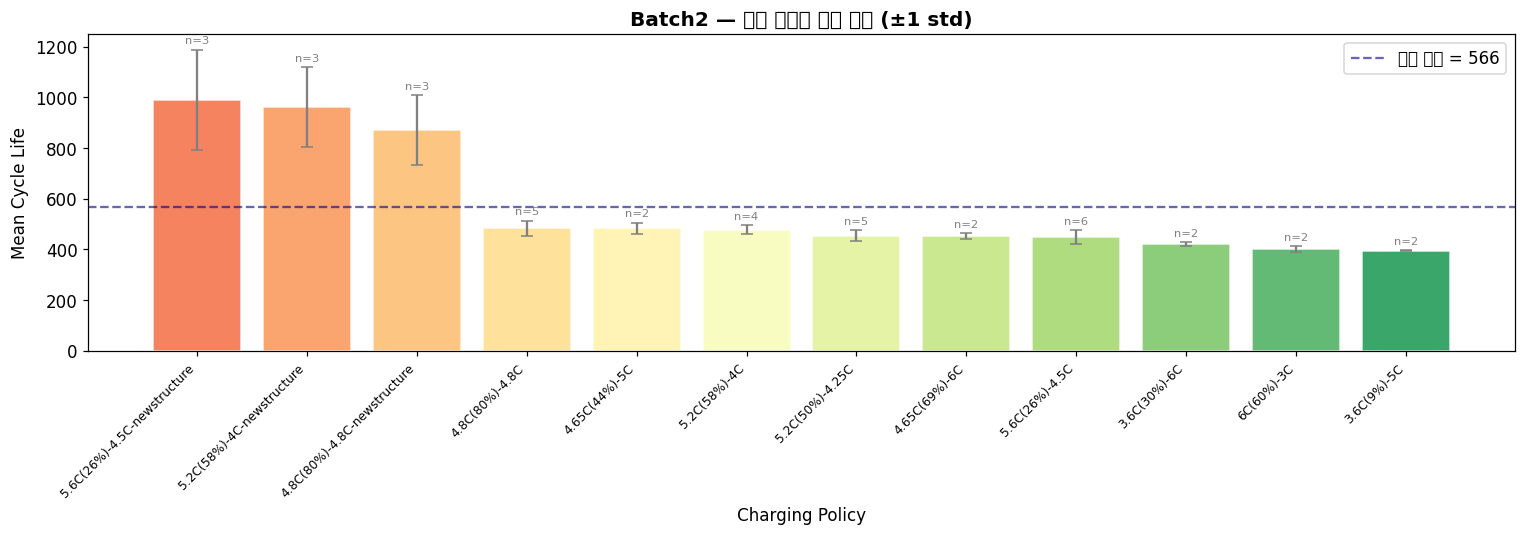

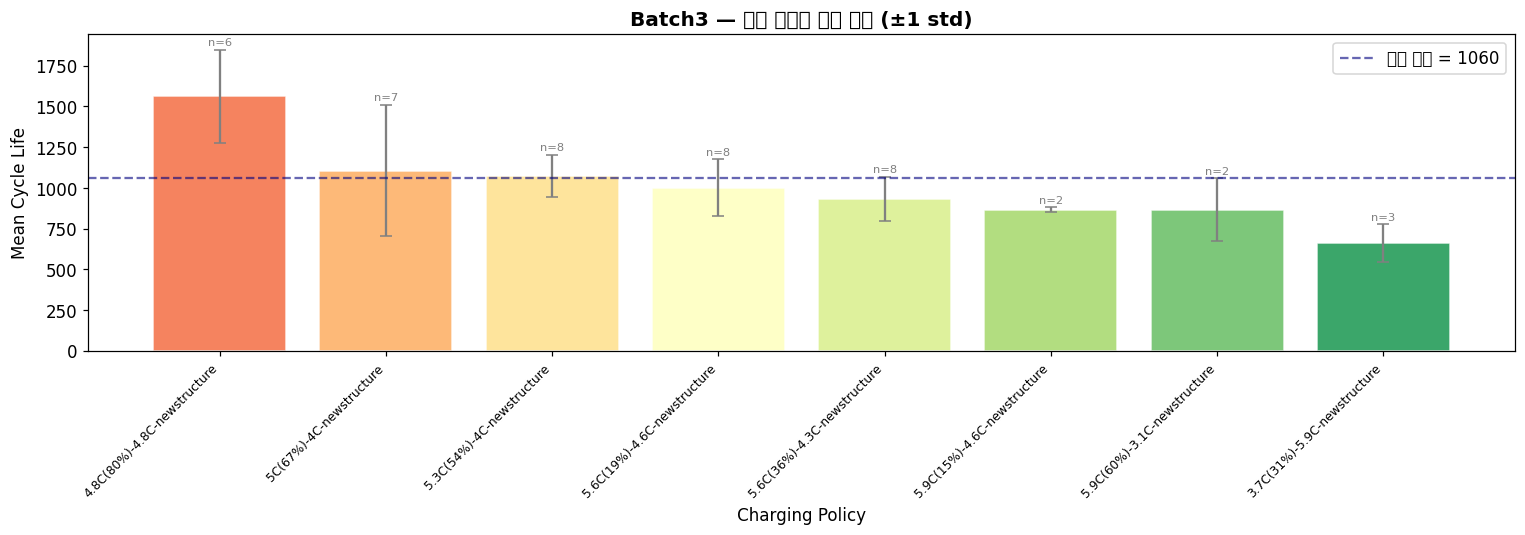

In [ ]:
for bname in LOADED_BATCHES:
    meta = all_meta[bname]
    policy_life = (
        meta.groupby('charging_policy')['cycle_life']
        .agg(['mean', 'std', 'count'])
        .sort_values('mean', ascending=False)
    )
    policy_life['std'] = policy_life['std'].fillna(0)

    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(policy_life))
    colors = [cm.RdYlGn(v) for v in np.linspace(0.2, 0.9, len(policy_life))]

    bars = ax.bar(x, policy_life['mean'], yerr=policy_life['std'],
                  color=colors, alpha=0.85, edgecolor='white',
                  error_kw=dict(ecolor='gray', capsize=4))
    ax.axhline(meta['cycle_life'].mean(), color='navy', linestyle='--', alpha=0.6,
               label=f'전체 평균 = {meta["cycle_life"].mean():.0f}')
    ax.set_xticks(list(x))
    ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Charging Policy')
    ax.set_ylabel('Mean Cycle Life')
    ax.set_title(f'{bname} — 충전 정책별 평균 수명 (±1 std)', fontweight='bold')
    for bar, (_, row) in zip(bars, policy_life.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + row['std'] + 15,
                f'n={int(row["count"])}', ha='center', va='bottom', fontsize=7.5, color='gray')
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'q4_{bname}_policy_bar.png', dpi=130)
    plt.show()

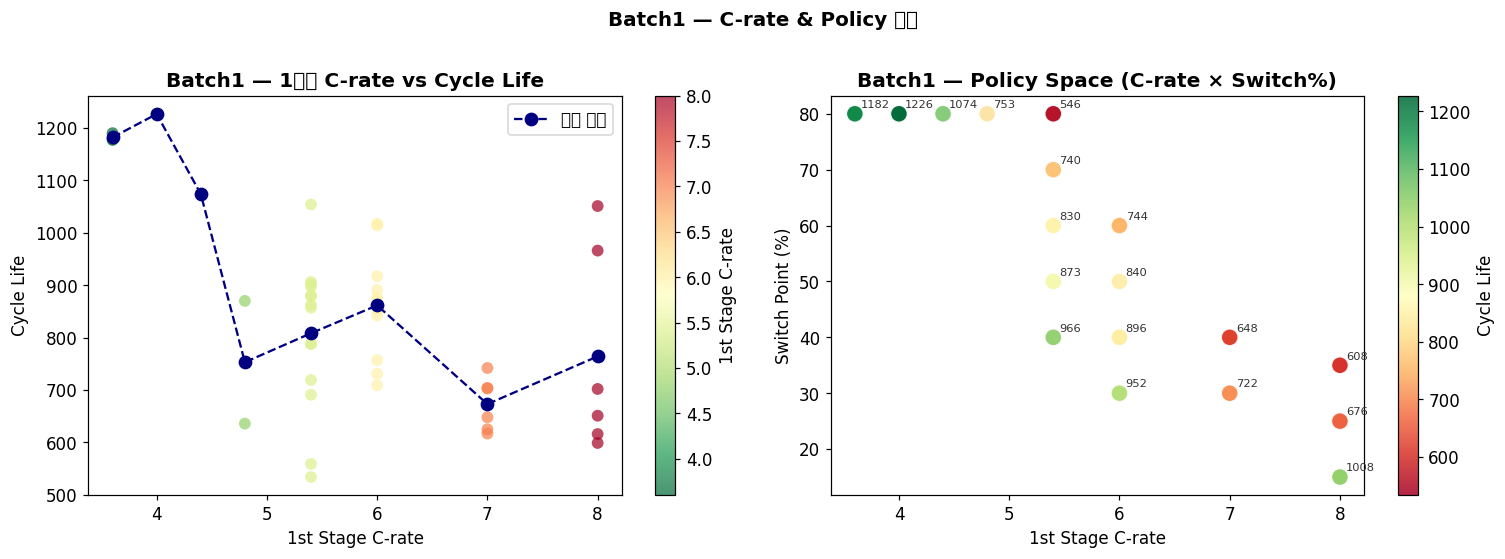

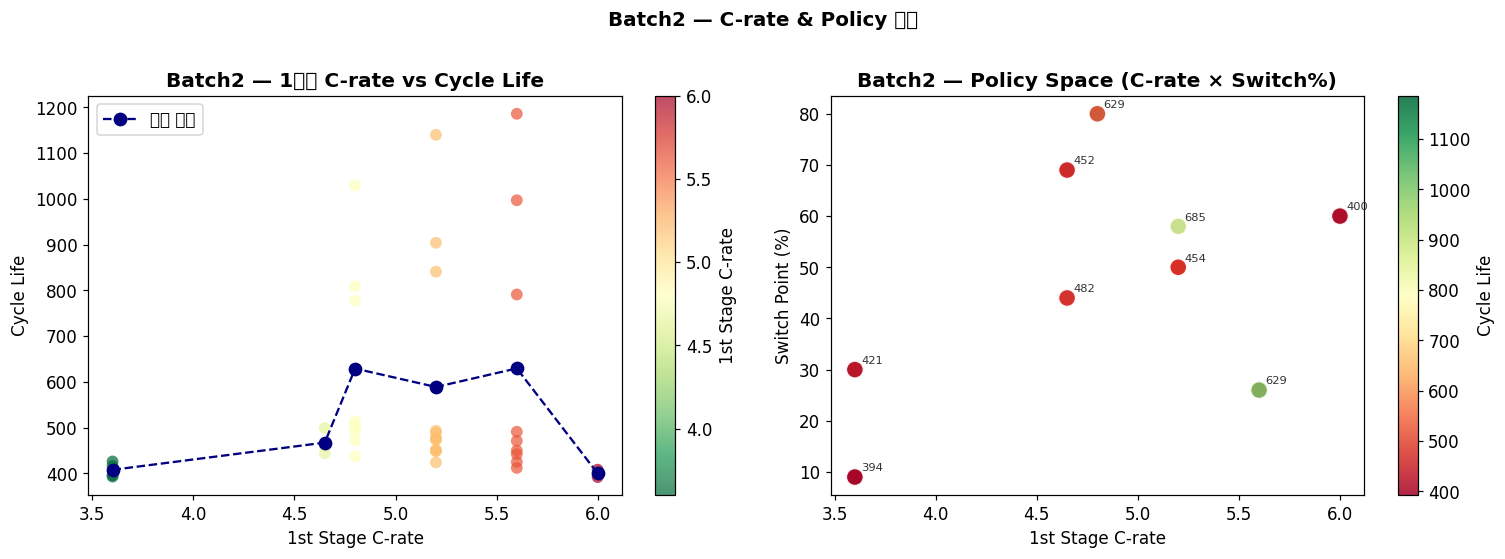

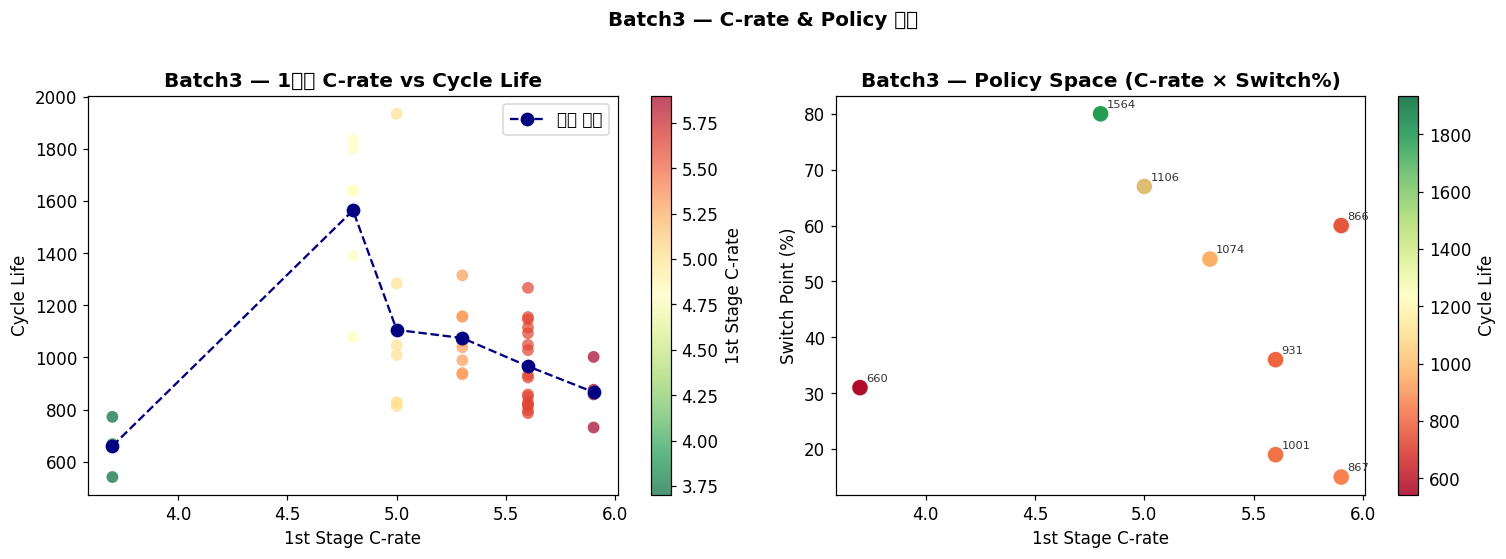

In [ ]:
for bname in LOADED_BATCHES:
    meta = all_meta[bname]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1단계 C-rate vs Cycle Life
    ax = axes[0]
    sc = ax.scatter(meta['c1'], meta['cycle_life'],
                    c=meta['c1'], cmap='RdYlGn_r', alpha=0.7, s=60, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='1st Stage C-rate')
    grp = meta.groupby('c1')['cycle_life'].mean()
    ax.plot(grp.index, grp.values, 'o--', color='navy', markersize=8, linewidth=1.5, label='그룹 평균')
    ax.set_xlabel('1st Stage C-rate')
    ax.set_ylabel('Cycle Life')
    ax.set_title(f'{bname} — 1단계 C-rate vs Cycle Life', fontweight='bold')
    ax.legend()

    # Policy Space: C-rate × Switch% → Cycle Life
    ax = axes[1]
    valid_sw = meta.dropna(subset=['c1', 'switch_pct', 'cycle_life'])
    if len(valid_sw) > 0:
        sc2 = ax.scatter(valid_sw['c1'], valid_sw['switch_pct'],
                         c=valid_sw['cycle_life'], cmap='RdYlGn', alpha=0.85, s=120,
                         edgecolors='white', linewidths=0.8,
                         vmin=meta['cycle_life'].min(), vmax=meta['cycle_life'].max())
        plt.colorbar(sc2, ax=ax, label='Cycle Life')
        pm = valid_sw.groupby(['c1', 'switch_pct'])['cycle_life'].mean()
        for (c1v, sw), lv in pm.items():
            ax.annotate(f'{lv:.0f}', xy=(c1v, sw), xytext=(4, 4),
                        textcoords='offset points', fontsize=7.5, color='#333')
        ax.set_xlabel('1st Stage C-rate')
        ax.set_ylabel('Switch Point (%)')
        ax.set_title(f'{bname} — Policy Space (C-rate × Switch%)', fontweight='bold')

    plt.suptitle(f'{bname} — C-rate & Policy 분석', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'q4_{bname}_crate_scatter.png', dpi=130, bbox_inches='tight')
    plt.show()

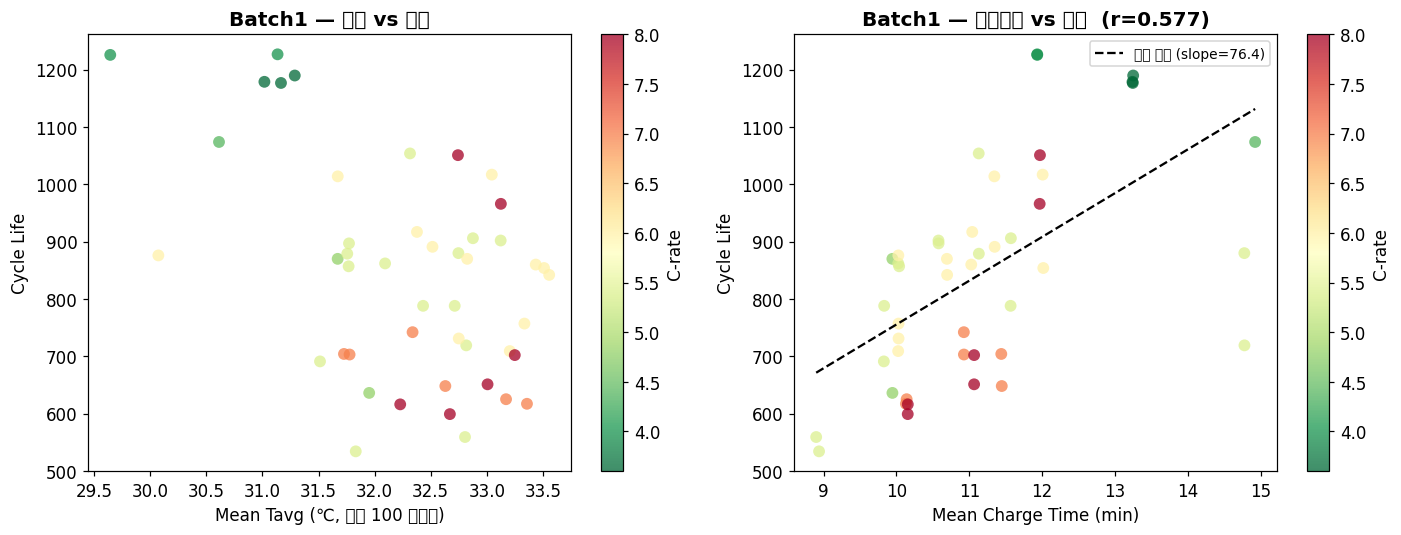

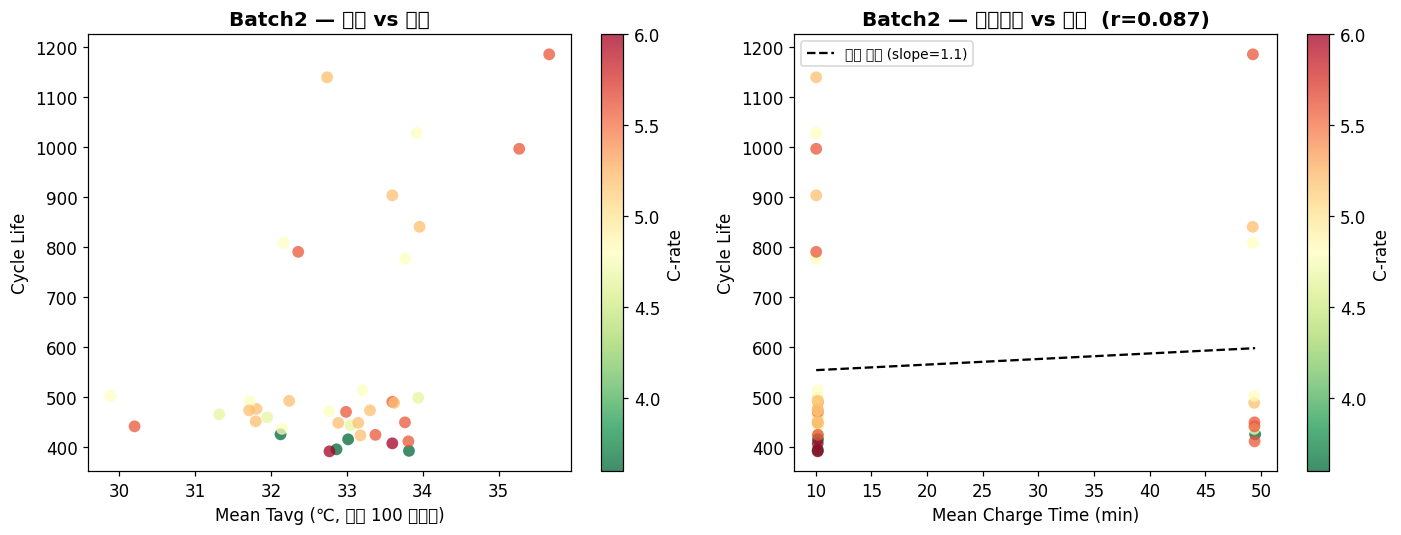

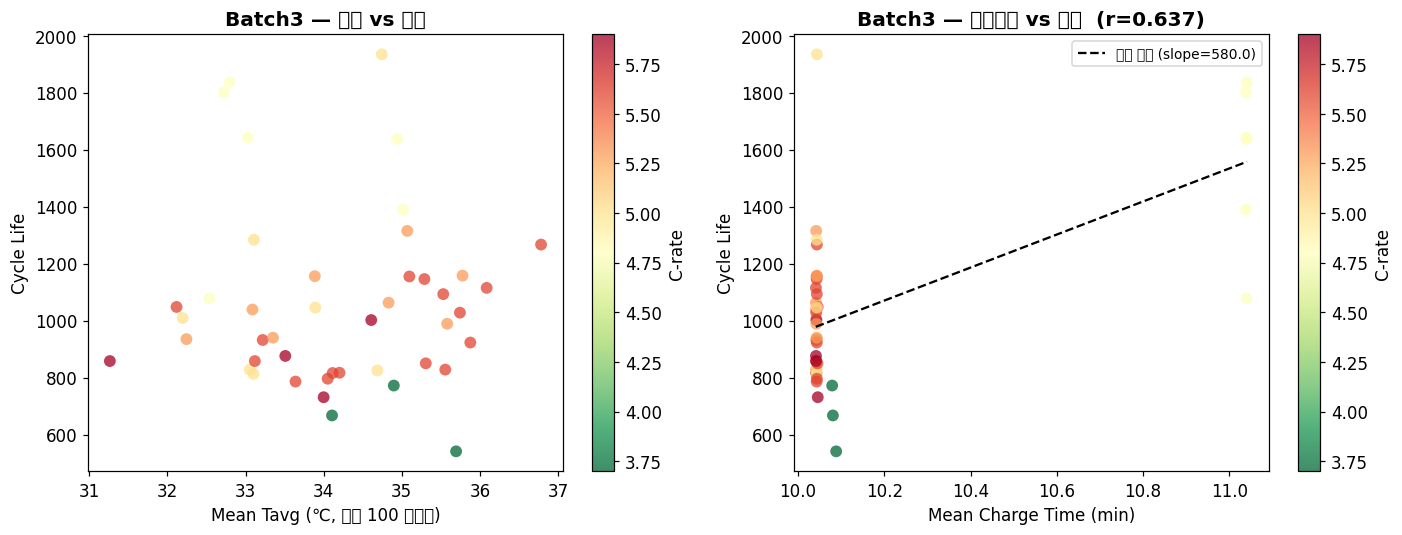

In [ ]:
for bname in LOADED_BATCHES:
    df   = all_df[bname]
    meta = all_meta[bname]

    early = (
        df[df['cycle'] <= 100].groupby('cell_id')
        .agg(mean_Tavg=('Tavg','mean'), mean_Tmax=('Tmax','mean'),
             mean_chargetime=('chargetime','mean'))
        .reset_index()
    )
    meta_e = meta.merge(early, on='cell_id')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 온도 vs 수명
    ax = axes[0]
    sc = ax.scatter(meta_e['mean_Tavg'], meta_e['cycle_life'],
                    c=meta_e['c1'], cmap='RdYlGn_r', alpha=0.75, s=60, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='C-rate')
    ax.set_xlabel('Mean Tavg (℃, 초기 100 사이클)')
    ax.set_ylabel('Cycle Life')
    ax.set_title(f'{bname} — 온도 vs 수명', fontweight='bold')

    # 충전시간 vs 수명 + 회귀선
    ax = axes[1]
    sc2 = ax.scatter(meta_e['mean_chargetime'], meta_e['cycle_life'],
                     c=meta_e['c1'], cmap='RdYlGn_r', alpha=0.75, s=60, edgecolors='none')
    plt.colorbar(sc2, ax=ax, label='C-rate')
    x_ct = meta_e['mean_chargetime'].values
    y_cl = meta_e['cycle_life'].values
    valid = np.isfinite(x_ct) & np.isfinite(y_cl)
    if valid.sum() > 2:
        z = np.polyfit(x_ct[valid], y_cl[valid], 1)
        xr = np.linspace(x_ct[valid].min(), x_ct[valid].max(), 100)
        ax.plot(xr, np.poly1d(z)(xr), 'k--', linewidth=1.5,
                label=f'선형 회귀 (slope={z[0]:.1f})')
        r = np.corrcoef(x_ct[valid], y_cl[valid])[0, 1]
        ax.set_title(f'{bname} — 충전시간 vs 수명  (r={r:.3f})', fontweight='bold')
    ax.set_xlabel('Mean Charge Time (min)')
    ax.set_ylabel('Cycle Life')
    ax.legend(fontsize=9)

    plt.tight_layout()
    fig.savefig(FIG_DIR / f'q4_{bname}_temp_chargetime.png', dpi=130)
    plt.show()

---
## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?

- 초기 사이클 피처와 Cycle Life 상관 계수
- Batch별 비교 히트맵
- VIF (다중공선성) 분석

In [ ]:
FEATURE_COLS = ['mean_QD', 'std_QD', 'mean_QC', 'mean_IR',
                'mean_Tavg', 'mean_Tmax', 'mean_Tmin', 'mean_chargetime']

early_batch = {}
for bname in LOADED_BATCHES:
    df = all_df[bname]
    early = (
        df[df['cycle'] <= 100].groupby('cell_id')
        .agg(
            cycle_life=('cycle_life', 'first'),
            mean_QD=('QD', 'mean'),  std_QD=('QD', 'std'),
            mean_QC=('QC', 'mean'),  mean_IR=('IR', 'mean'),
            mean_Tavg=('Tavg', 'mean'), mean_Tmax=('Tmax', 'mean'),
            mean_Tmin=('Tmin', 'mean'), mean_chargetime=('chargetime', 'mean'),
        )
        .reset_index()
    )
    early['batch'] = bname
    early_batch[bname] = early
    print(f'[{bname}] 초기 피처 셀 수: {len(early)}')

early_all = pd.concat(early_batch.values(), ignore_index=True)
print(f'\n전체 합산 셀 수: {len(early_all)}')

[Batch1] 초기 피처 셀 수: 46
[Batch2] 초기 피처 셀 수: 39
[Batch3] 초기 피처 셀 수: 44

전체 합산 셀 수: 129


In [ ]:
print('='*65)
print('Q5. 피처-Cycle Life 상관계수 순위')
print('='*65)

for bname in LOADED_BATCHES:
    early = early_batch[bname]
    corr = (
        early[FEATURE_COLS + ['cycle_life']]
        .corr(numeric_only=True)['cycle_life']
        .drop('cycle_life')
        .sort_values(key=abs, ascending=False)
    )
    print(f'\n[{bname}]')
    for feat, r in corr.items():
        bar = '█' * int(abs(r) * 20)
        sign = '+' if r > 0 else '-'
        print(f'  {feat:20s}  {sign}{abs(r):.4f}  {bar}')

Q5. 피처-Cycle Life 상관계수 순위

[Batch1]
  mean_chargetime       +0.5770  ███████████
  mean_Tavg             -0.4818  █████████
  mean_Tmin             -0.4177  ████████
  mean_Tmax             -0.4036  ████████
  mean_QD               +0.1934  ███
  mean_IR               +0.1766  ███
  std_QD                -0.0900  █
  mean_QC               -0.0589  █

[Batch2]
  mean_Tmin             +0.5396  ██████████
  mean_Tavg             +0.4246  ████████
  mean_IR               -0.3525  ███████
  mean_QD               -0.3321  ██████
  mean_QC               -0.3057  ██████
  std_QD                +0.1707  ███
  mean_chargetime       +0.0870  █
  mean_Tmax             +0.0190  

[Batch3]
  mean_chargetime       +0.6375  ████████████
  std_QD                -0.3562  ███████
  mean_QC               +0.2224  ████
  mean_QD               +0.2175  ████
  mean_IR               +0.1902  ███
  mean_Tmax             -0.1065  ██
  mean_Tavg             -0.0218  
  mean_Tmin             +0.0169  


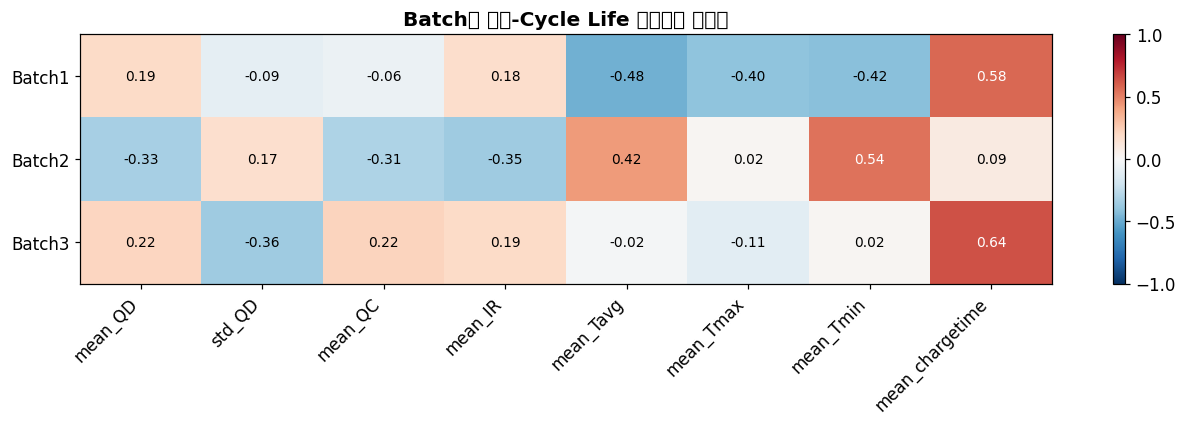


상관계수 테이블:


,mean_QD,std_QD,mean_QC,mean_IR,mean_Tavg,mean_Tmax,mean_Tmin,mean_chargetime
Batch1,0.193,-0.090,-0.059,0.177,-0.482,-0.404,-0.418,0.577
Batch2,-0.332,0.171,-0.306,-0.353,0.425,0.019,0.540,0.087
Batch3,0.217,-0.356,0.222,0.190,-0.022,-0.106,0.017,0.637


In [ ]:
# Batch별 상관계수 히트맵
matrix = []
for bname in LOADED_BATCHES:
    early = early_batch[bname]
    corr = (
        early[FEATURE_COLS + ['cycle_life']]
        .corr(numeric_only=True)['cycle_life']
        .drop('cycle_life')
        .reindex(FEATURE_COLS)
    )
    matrix.append(corr.values)

corr_df = pd.DataFrame(matrix, index=LOADED_BATCHES, columns=FEATURE_COLS)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(corr_df, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(LOADED_BATCHES)))
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha='right')
ax.set_yticklabels(LOADED_BATCHES)
for i in range(len(LOADED_BATCHES)):
    for j in range(len(FEATURE_COLS)):
        val = corr_df.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)
ax.set_title('Batch별 피처-Cycle Life 상관계수 히트맵', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'q5_batch_corr_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n상관계수 테이블:')
display(corr_df.round(3))

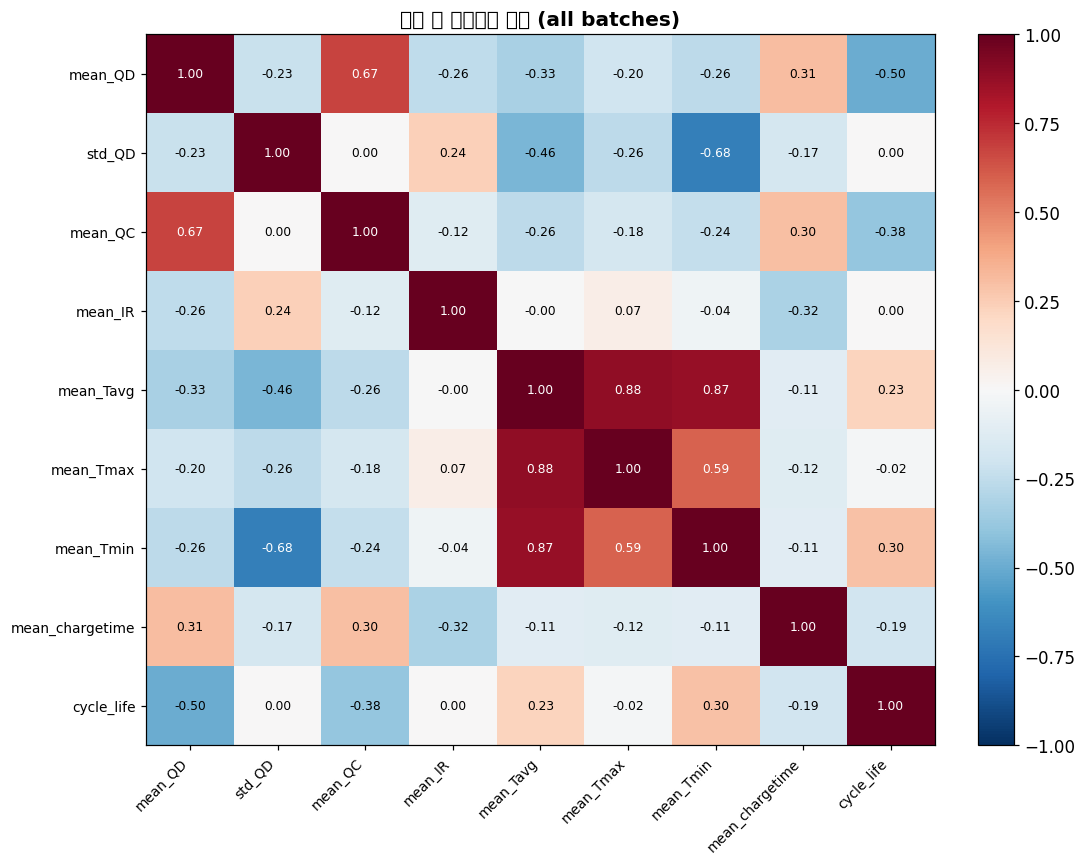

In [ ]:
# 피처 간 상관관계 (전체 배치)
C_full = early_all[FEATURE_COLS + ['cycle_life']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(C_full.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046)
labels = C_full.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        val = C_full.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
ax.set_title('전체 쌍 상관관계 행렬 (all batches)', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'q5_full_corr_matrix.png', dpi=130)
plt.show()


VIF 테이블 (전체 배치 합산):


,feature,r2,VIF
4,mean_Tavg,0.9745,39.22
6,mean_Tmin,0.9422,17.31
5,mean_Tmax,0.9273,13.76
1,std_QD,0.7250,3.64
0,mean_QD,0.6841,3.17
2,mean_QC,0.5157,2.06
7,mean_chargetime,0.2628,1.36
3,mean_IR,0.1986,1.25


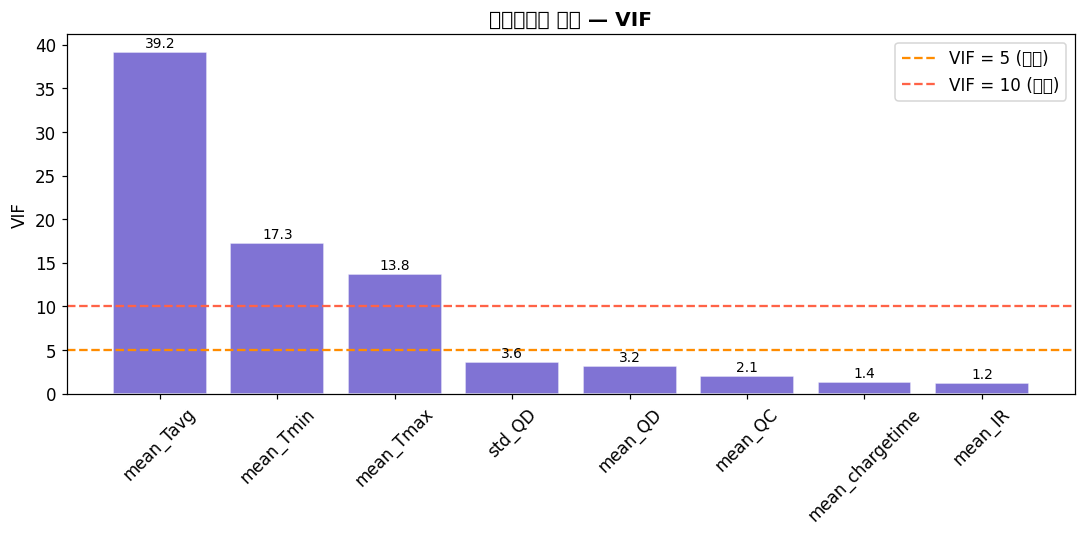

In [ ]:
# VIF (다중공선성) 분석
vif_input = early_all[FEATURE_COLS].dropna()
vif_table = compute_vif(vif_input)

print('\nVIF 테이블 (전체 배치 합산):')
display(vif_table)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(vif_table['feature'], vif_table['VIF'],
              color='slateblue', alpha=0.85, edgecolor='white')
ax.axhline(5,  color='darkorange', linestyle='--', linewidth=1.5, label='VIF = 5 (주의)')
ax.axhline(10, color='tomato',     linestyle='--', linewidth=1.5, label='VIF = 10 (심각)')
for bar, row in zip(bars, vif_table.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{row.VIF:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('VIF')
ax.set_title('다중공선성 진단 — VIF', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / 'q5_vif_bar.png', dpi=130)
plt.show()

---
## 분석 요약

In [ ]:
print('='*65)
print('EDA 통합 분석 요약')
print('='*65)

for bname in LOADED_BATCHES:
    meta = all_meta[bname]
    cl = meta['cycle_life'].values
    print(f'\n[{bname}]')
    print(f'  Q1 - 셀 수: {len(cl)}')
    print(f'       장수명(>1000): {100*np.mean(cl>1000):.1f}%, 단수명(<500): {100*np.mean(cl<500):.1f}%')

    if bname in all_dq and not all_dq[bname].empty:
        dq = all_dq[bname]
        r_dq = np.corrcoef(dq['cycle_life'], dq['dq_abs_mean'])[0,1]
        print(f'  Q3 - ΔQ abs_mean vs cycle_life r: {r_dq:+.4f}')

    early = early_batch[bname]
    top_feat = (
        early[FEATURE_COLS + ['cycle_life']]
        .corr(numeric_only=True)['cycle_life']
        .drop('cycle_life')
        .abs().idxmax()
    )
    top_r = early[FEATURE_COLS + ['cycle_life']].corr(numeric_only=True)['cycle_life'].drop('cycle_life').abs().max()
    print(f'  Q5 - 수명과 가장 상관 높은 피처: {top_feat} (|r|={top_r:.4f})')

print(f'\n생성된 그림 경로: {FIG_DIR}')
import glob
for f in sorted(glob.glob(str(FIG_DIR / 'q*.png'))):
    print(f'  {Path(f).name}')

EDA 통합 분석 요약

[Batch1]
  Q1 - 셀 수: 46
       장수명(>1000): 21.7%, 단수명(<500): 0.0%
  Q3 - ΔQ abs_mean vs cycle_life r: -0.8538
  Q5 - 수명과 가장 상관 높은 피처: mean_chargetime (|r|=0.5770)

[Batch2]
  Q1 - 셀 수: 39
       장수명(>1000): 7.7%, 단수명(<500): 71.8%
  Q3 - ΔQ abs_mean vs cycle_life r: -0.7649
  Q5 - 수명과 가장 상관 높은 피처: mean_Tmin (|r|=0.5396)

[Batch3]
  Q1 - 셀 수: 44
       장수명(>1000): 52.3%, 단수명(<500): 0.0%
  Q3 - ΔQ abs_mean vs cycle_life r: -0.6294
  Q5 - 수명과 가장 상관 높은 피처: mean_chargetime (|r|=0.6375)

생성된 그림 경로: /Users/toucan/Documents/workspace/ESS/figures/eda_day1
  q1_cycle_life_boxplot.png
  q1_cycle_life_hist.png
  q2_Batch1_degradation_curve.png
  q2_Batch1_knee_point.png
  q2_Batch2_degradation_curve.png
  q2_Batch2_knee_point.png
  q2_Batch3_degradation_curve.png
  q2_Batch3_knee_point.png
  q3_Batch1_delta_q.png
  q3_Batch2_delta_q.png
  q3_Batch3_delta_q.png
  q4_Batch1_crate_scatter.png
  q4_Batch1_policy_bar.png
  q4_Batch1_temp_chargetime.png
  q4_Batch2_crate_scatter.png
  q4_Ba